# One-period debt with ECB-style LOLR intervention

This notebook runs the ECB model in Section 2 of `docs/LOLR_oneperioddebt_vsunspot.pdf`. The ECB changes the lenders' return in the low-growth, bad-sunspot repayment state; it does not add a sovereign LOLR debt state.

In [172]:
include("src/simple_s_lolrECB.jl")
using Plots
Plots.default(left_margin = 14Plots.mm, right_margin = 10Plots.mm,
    bottom_margin = 12Plots.mm, top_margin = 10Plots.mm)
using Printf
using Serialization
using Statistics

result_dir = joinpath(pwd(), "result")
figure_dir = joinpath(result_dir, "figures")
grid_dir = joinpath(result_dir, "policy_grid")
foreach(mkpath, (result_dir, figure_dir, grid_dir))

## Solve Or Load Baseline

Set `force_resolve = true` when changing equations or solver tolerances. Otherwise the cell loads a saved solution when the baseline parameters match.

In [173]:
baseline_parameters = (
    Nb = 1000,
    Ne = 17,
    ecb_spread = 0.04,
    intervention_prob = 0.50,
)
baseline_cache_path = joinpath(result_dir, "s_lolrECB_baseline_solution.jls")
force_resolve = false

model = init_model(Model(; baseline_parameters...))
guess_sol = nothing

if !force_resolve && isfile(baseline_cache_path)
    cached = deserialize(baseline_cache_path)

    if cached.parameters == baseline_parameters
        guess_sol = cached.sol
        println("Using saved solution as initial guess: ", baseline_cache_path)
    end
end

sol = solve_model(model; sol = guess_sol, verbose = true)

serialize(
    baseline_cache_path,
    (parameters = baseline_parameters, model = model, sol = sol),
)
println("Saved updated baseline solution: ", baseline_cache_path)

Using saved solution as initial guess: /Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolrECB/result/s_lolrECB_baseline_solution.jls
iter=1, vnd_err=4.0661318045920325e-7, vd_err=4.0739078777107807e-8, x_err=9.239649712000642e-8
Saved updated baseline solution: /Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolrECB/result/s_lolrECB_baseline_solution.jls


## Plots After Solving, Before Simulation

The cells below inspect equilibrium schedules and policies before simulated moments are computed.

In [174]:
# Common indexes used in the pre-simulation figures.
g_low = argmin(model.g)
g_high = argmax(model.g)
s_bad = 1
s_good = model.Ns
eps_mid = cld(model.Ne, 2)
bad_mask = sol.schedule_mask[:, g_low, s_bad]
good_mask = sol.schedule_mask[:, g_low, s_good]
nothing

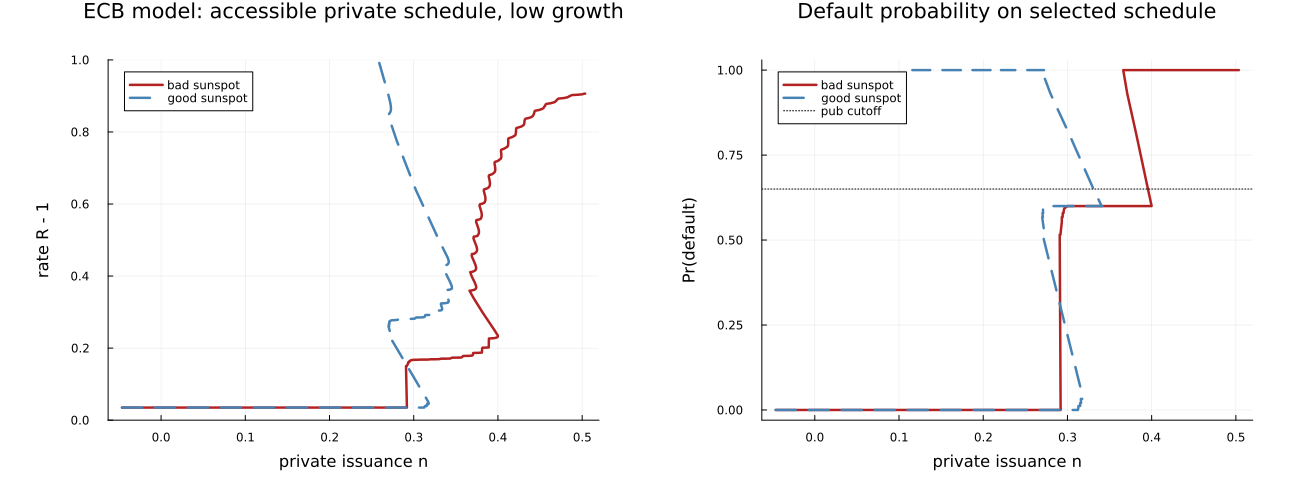

In [175]:
# Accessible private rate schedule and its default probability in low growth.
p_schedule = plot(sol.n[bad_mask, g_low, s_bad], sol.R[bad_mask, g_low, s_bad] .- 1,
    color = :firebrick, linewidth = 2.5, label = "bad sunspot",
    xlabel = "private issuance n", ylabel = "rate R - 1",
    title = "ECB model: accessible private schedule, low growth")
plot!(p_schedule, sol.n[good_mask, g_low, s_good], sol.R[good_mask, g_low, s_good] .- 1,
    color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good sunspot", ylims = (0, 1))

p_pdefault = plot(sol.n[bad_mask, g_low, s_bad], sol.pdefault[bad_mask, g_low, s_bad],
    color = :firebrick, linewidth = 2.5, label = "bad sunspot",
    xlabel = "private issuance n", ylabel = "Pr(default)",
    title = "Default probability on selected schedule")
plot!(p_pdefault, sol.n[good_mask, g_low, s_good], sol.pdefault[good_mask, g_low, s_good],
    color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good sunspot")
hline!(p_pdefault, [model.pub], color = :black, linestyle = :dot, label = "pub cutoff")

fig_schedule = plot(p_schedule, p_pdefault, layout = (1, 2), size = (1300, 500))
savefig(fig_schedule, joinpath(figure_dir, "ecb_selected_schedule.png"))
display(fig_schedule)

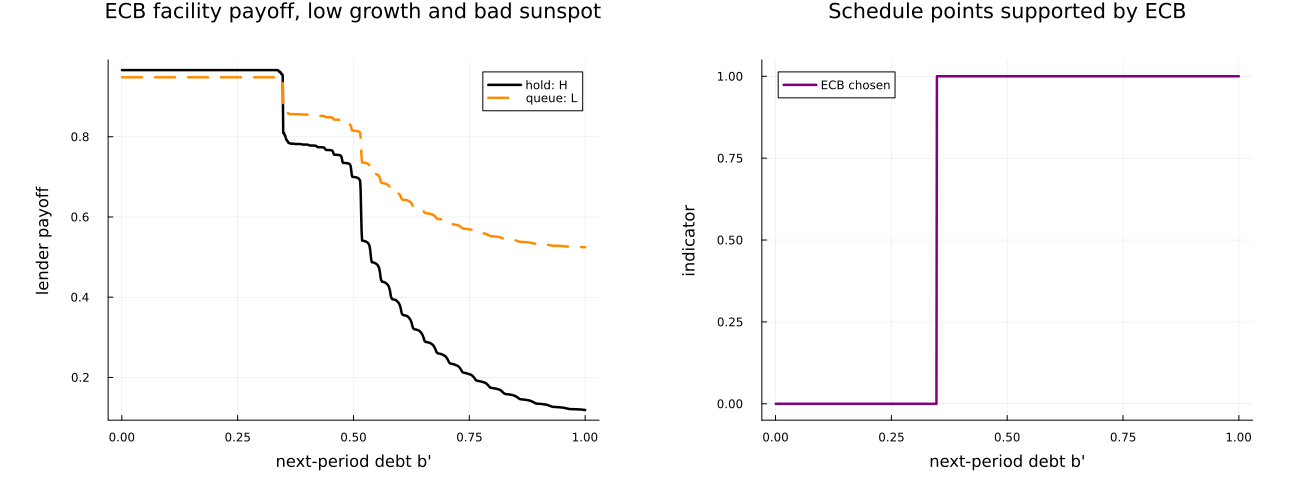

In [176]:
# ECB facility payoff: H is holding the bond, L is entering the facility queue.
positive_debt = model.b .> 0
p_facility = plot(model.b[positive_debt], sol.H[positive_debt, g_low, s_bad],
    color = :black, linewidth = 2.5, label = "hold: H",
    xlabel = "next-period debt b'", ylabel = "lender payoff",
    title = "ECB facility payoff, low growth and bad sunspot")
plot!(p_facility, model.b[positive_debt], sol.L[positive_debt, g_low, s_bad],
    color = :darkorange, linestyle = :dash, linewidth = 2.5, label = "queue: L")

p_support = plot(model.b[positive_debt], Float64.(sol.ecb_used[positive_debt, g_low, s_bad]),
    color = :purple, linewidth = 2.5, label = "ECB chosen",
    xlabel = "next-period debt b'", ylabel = "indicator",
    ylims = (-0.05, 1.05), title = "Schedule points supported by ECB")

fig_facility = plot(p_facility, p_support, layout = (1, 2), size = (1300, 500))
savefig(fig_facility, joinpath(figure_dir, "ecb_facility_payoff.png"))
display(fig_facility)

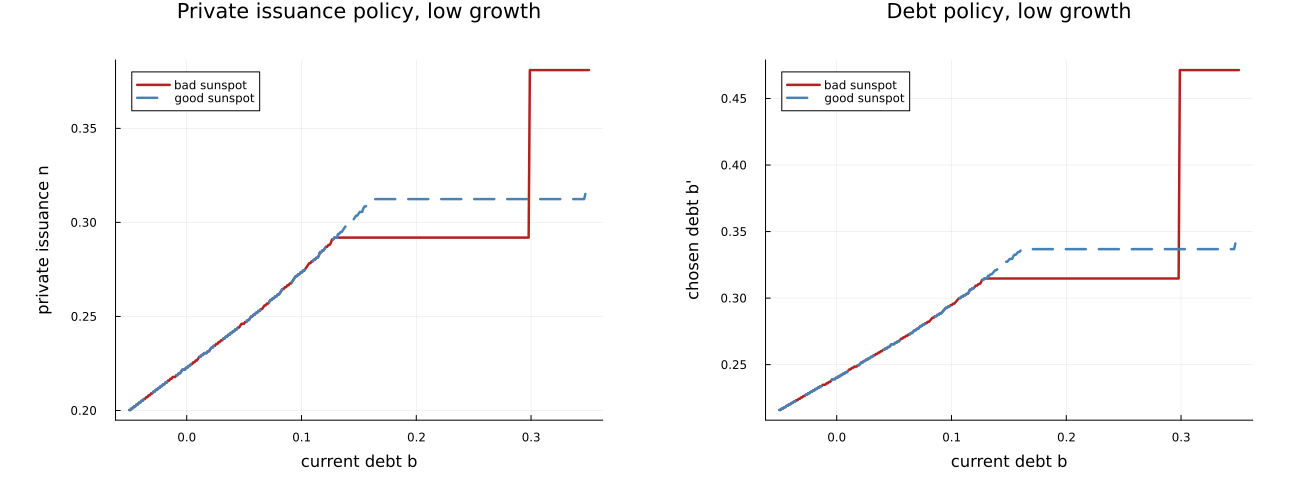

In [177]:
# Private issuance and debt policies as functions of current debt.
bp_low_bad = sol.b_policy_idx[:, g_low, s_bad, eps_mid]
bp_low_good = sol.b_policy_idx[:, g_low, s_good, eps_mid]
n_low_bad = sol.n[bp_low_bad, g_low, s_bad]
n_low_good = sol.n[bp_low_good, g_low, s_good]
repay_low_bad = .!sol.d[:, g_low, s_bad, eps_mid]
repay_low_good = .!sol.d[:, g_low, s_good, eps_mid]

p_n_policy = plot(model.b[repay_low_bad], n_low_bad[repay_low_bad],
    color = :firebrick, linewidth = 2.5, label = "bad sunspot",
    xlabel = "current debt b", ylabel = "private issuance n",
    title = "Private issuance policy, low growth")
plot!(p_n_policy, model.b[repay_low_good], n_low_good[repay_low_good],
    color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good sunspot")

p_b_policy = plot(model.b[repay_low_bad], model.b[bp_low_bad[repay_low_bad]],
    color = :firebrick, linewidth = 2.5, label = "bad sunspot",
    xlabel = "current debt b", ylabel = "chosen debt b'",
    title = "Debt policy, low growth")
plot!(p_b_policy, model.b[repay_low_good], model.b[bp_low_good[repay_low_good]],
    color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good sunspot")

fig_policy = plot(p_n_policy, p_b_policy, layout = (1, 2), size = (1300, 500))
savefig(fig_policy, joinpath(figure_dir, "ecb_private_policy.png"))
display(fig_policy)

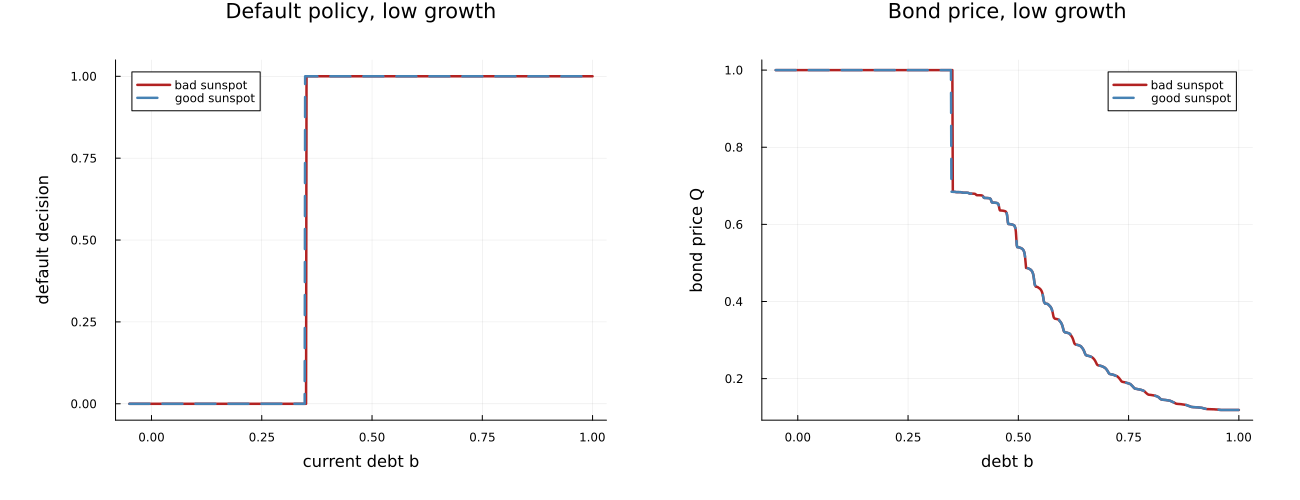

In [178]:
# Default decisions and bond prices for the middle endowment shock.
p_default = plot(model.b, Float64.(sol.d[:, g_low, s_bad, eps_mid]),
    color = :firebrick, linewidth = 2.5, label = "bad sunspot",
    xlabel = "current debt b", ylabel = "default decision",
    ylims = (-0.05, 1.05), title = "Default policy, low growth")
plot!(p_default, model.b, Float64.(sol.d[:, g_low, s_good, eps_mid]),
    color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good sunspot")

p_price = plot(model.b, sol.Q[:, g_low, s_bad, eps_mid],
    color = :firebrick, linewidth = 2.5, label = "bad sunspot",
    xlabel = "debt b", ylabel = "bond price Q",
    title = "Bond price, low growth")
plot!(p_price, model.b, sol.Q[:, g_low, s_good, eps_mid],
    color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good sunspot")

fig_default_price = plot(p_default, p_price, layout = (1, 2), size = (1300, 500))
savefig(fig_default_price, joinpath(figure_dir, "ecb_default_and_price.png"))
display(fig_default_price)

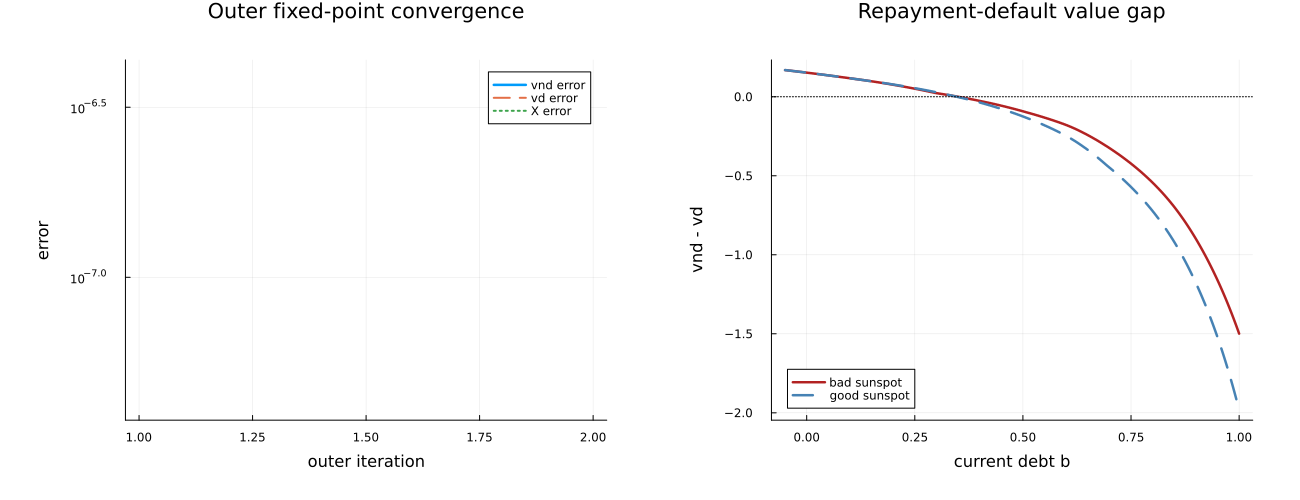

In [179]:
# Solver convergence and the repayment-default value gap.
p_errors = plot(sol.outer_errs, yscale = :log10, linewidth = 2.5, label = "vnd error",
    xlabel = "outer iteration", ylabel = "error", title = "Outer fixed-point convergence")
plot!(p_errors, sol.vd_errs, linestyle = :dash, linewidth = 2, label = "vd error")
plot!(p_errors, sol.x_errs, linestyle = :dot, linewidth = 2, label = "X error")

p_gap = plot(model.b, sol.vnd[:, g_low, s_bad, eps_mid] .- sol.vd[:, g_low, s_bad, eps_mid],
    color = :firebrick, linewidth = 2.5, label = "bad sunspot",
    xlabel = "current debt b", ylabel = "vnd - vd", title = "Repayment-default value gap")
plot!(p_gap, model.b, sol.vnd[:, g_low, s_good, eps_mid] .- sol.vd[:, g_low, s_good, eps_mid],
    color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good sunspot")
hline!(p_gap, [0.0], color = :black, linestyle = :dot, label = false)

fig_values = plot(p_errors, p_gap, layout = (1, 2), size = (1300, 500))
savefig(fig_values, joinpath(figure_dir, "ecb_convergence_and_value_gap.png"))
display(fig_values)

## Simulate Or Load Baseline

The simulated path is cached separately from the solved equilibrium because it can be regenerated with different horizons or random seeds.

In [180]:
simulation_parameters = (T = 200_000, burnin = 10_000, seed = 1234)
simulation_cache_path = joinpath(result_dir, "s_lolrECB_baseline_simulation.jls")
force_resimulate = false
loaded_simulation = false

if !force_resimulate && isfile(simulation_cache_path)
    cached_sim = deserialize(simulation_cache_path)
    if cached_sim.baseline_parameters == baseline_parameters && cached_sim.simulation_parameters == simulation_parameters
        sim, stats = cached_sim.sim, cached_sim.stats
        loaded_simulation = true
        println("Loaded simulation: ", simulation_cache_path)
    end
end

if force_resimulate || !loaded_simulation
    sim = simulate(model, sol; T = simulation_parameters.T, seed = simulation_parameters.seed)
    stats = summarize_simulation(sim, model; burnin = simulation_parameters.burnin)
    serialize(simulation_cache_path, (baseline_parameters = baseline_parameters,
        simulation_parameters = simulation_parameters, sim = sim, stats = stats))
    println("Saved simulation: ", simulation_cache_path)
end

stats

Loaded simulation: /Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolrECB/result/s_lolrECB_baseline_simulation.jls


(default_rate = 0.14893157894736841, mean_b_to_gdp = 0.4321124506945973, mean_n_to_gdp = 0.2950131817077468, mean_credit_spread = 0.08791091665592185, crisis_share = 0.03224736842105263, ecb_support_share = 0.024657894736842104, ecb_support_share_in_crisis = 0.7646482781132692, mean_ecb_sale_probability = 0.5, sample_size = 190000)

## Plots After Simulation

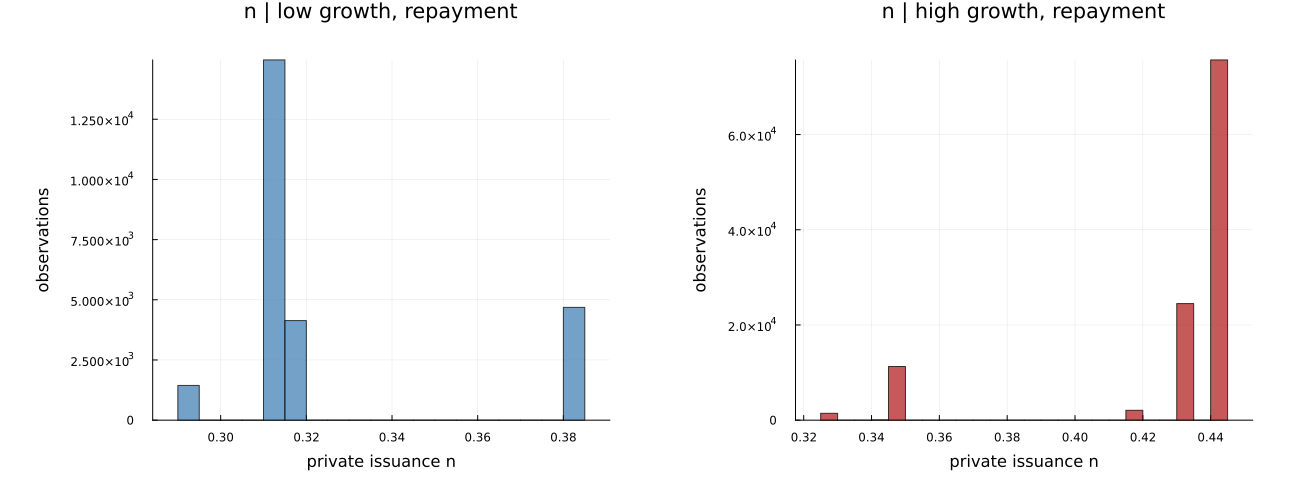

In [181]:
# Distribution of private issuance by growth state, conditional on repayment.
sample_idx = (simulation_parameters.burnin + 1):length(sim.b)
repay_sample = .!sim.default[sample_idx]
low_sample = sim.g_idx[sample_idx] .== g_low
high_sample = sim.g_idx[sample_idx] .== g_high

p_n_low = histogram(sim.n[sample_idx][repay_sample .& low_sample], bins = 40,
    color = :steelblue, alpha = 0.75, legend = false,
    xlabel = "private issuance n", ylabel = "observations",
    title = "n | low growth, repayment")
p_n_high = histogram(sim.n[sample_idx][repay_sample .& high_sample], bins = 40,
    color = :firebrick, alpha = 0.75, legend = false,
    xlabel = "private issuance n", ylabel = "observations",
    title = "n | high growth, repayment")

fig_issuance_dist = plot(p_n_low, p_n_high, layout = (1, 2), size = (1300, 500))
savefig(fig_issuance_dist, joinpath(figure_dir, "ecb_issuance_distribution.png"))
display(fig_issuance_dist)

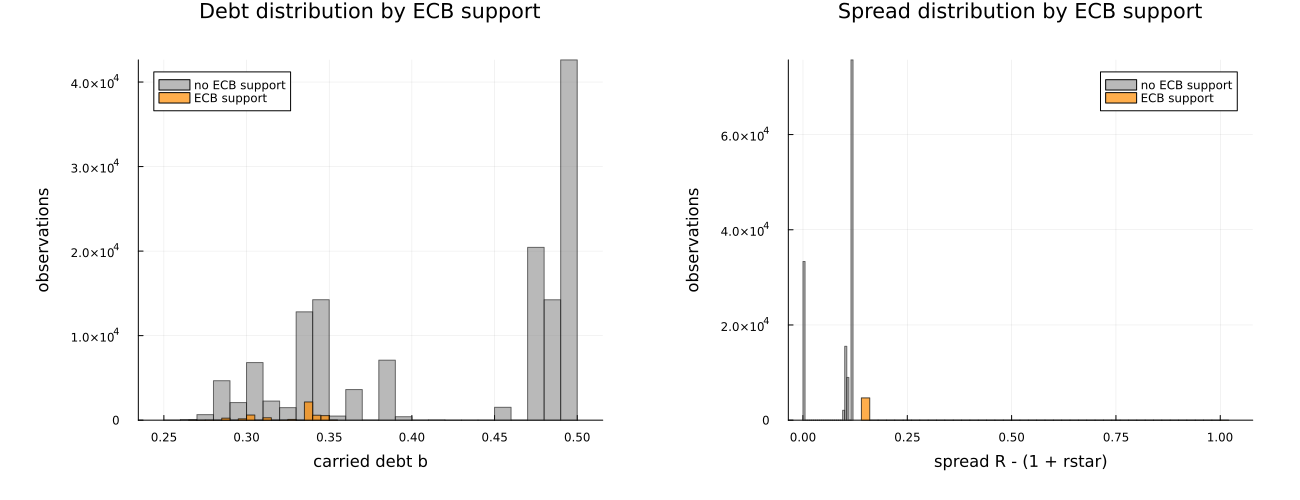

In [205]:
# Debt and spreads in repayment periods with and without ECB support.
ecb_sample = sim.ecb_used[sample_idx] .& repay_sample
market_sample = repay_sample .& .!sim.ecb_used[sample_idx]
spread_sample = sim.R[sample_idx] .- (1 + model.rstar)

p_debt_support = histogram(sim.b[sample_idx][market_sample], bins = 40,
    color = :gray, alpha = 0.55, label = "no ECB support",
    xlabel = "carried debt b", ylabel = "observations",
    title = "Debt distribution by ECB support")
histogram!(p_debt_support, sim.b[sample_idx][ecb_sample], bins = 40,
    color = :darkorange, alpha = 0.70, label = "ECB support")

p_spread_support = histogram(spread_sample[market_sample .& isfinite.(spread_sample)], bins = 40,
    color = :gray, alpha = 0.55, label = "no ECB support",
    xlabel = "spread R - (1 + rstar)", ylabel = "observations",
    title = "Spread distribution by ECB support")
histogram!(p_spread_support, [spread_sample[ecb_sample .& isfinite.(spread_sample)]; 1.0], bins = 40,
    color = :darkorange, alpha = 0.70, label = "ECB support")

fig_support_dist = plot(p_debt_support, p_spread_support, layout = (1, 2), size = (1300, 500))
savefig(fig_support_dist, joinpath(figure_dir, "ecb_support_distributions.png"))
display(fig_support_dist)

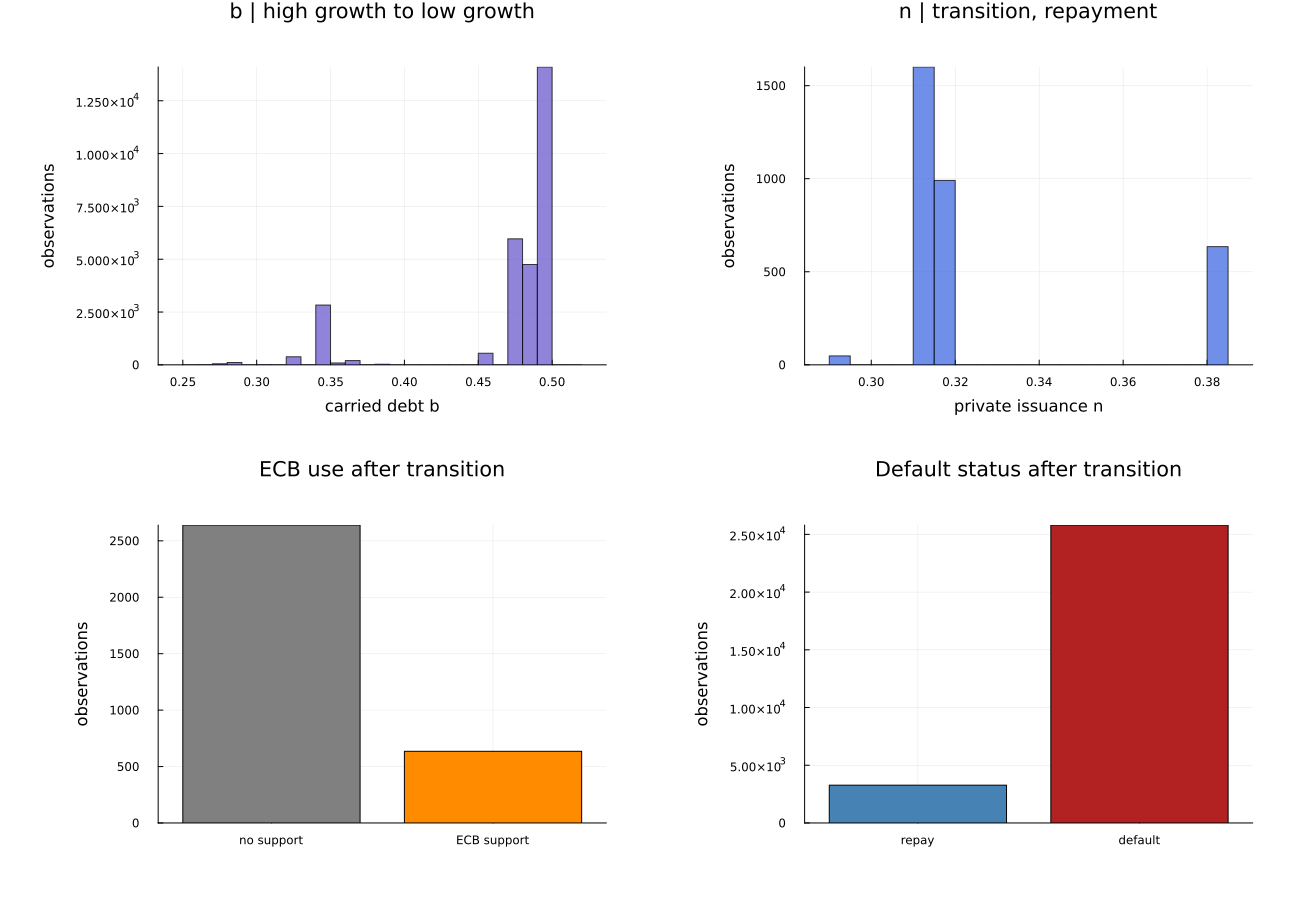

In [183]:
# Outcomes around high-growth to low-growth transitions.
high_to_low = falses(length(sim.b))
for t in 2:length(sim.b)
    high_to_low[t] = sim.g_idx[t - 1] == g_high && sim.g_idx[t] == g_low
end
transition = high_to_low[sample_idx]
transition_repay = transition .& repay_sample

p_transition_b = histogram(sim.b[sample_idx][transition], bins = 40,
    color = :slateblue, alpha = 0.75, legend = false,
    xlabel = "carried debt b", ylabel = "observations",
    title = "b | high growth to low growth")
p_transition_n = histogram(sim.n[sample_idx][transition_repay], bins = 40,
    color = :royalblue, alpha = 0.75, legend = false,
    xlabel = "private issuance n", ylabel = "observations",
    title = "n | transition, repayment")
p_transition_support = bar(["no support", "ECB support"],
    [sum(transition_repay .& .!sim.ecb_used[sample_idx]), sum(transition_repay .& sim.ecb_used[sample_idx])],
    color = [:gray, :darkorange], legend = false, ylabel = "observations",
    title = "ECB use after transition")
p_transition_default = bar(["repay", "default"],
    [sum(transition .& .!sim.default[sample_idx]), sum(transition .& sim.default[sample_idx])],
    color = [:steelblue, :firebrick], legend = false, ylabel = "observations",
    title = "Default status after transition")

fig_transition = plot(p_transition_b, p_transition_n, p_transition_support, p_transition_default,
    layout = (2, 2), size = (1300, 900))
savefig(fig_transition, joinpath(figure_dir, "ecb_transition_distributions.png"))
display(fig_transition)

## Baseline ECB Moments Table

This cell reports the ECB baseline results in one standalone LaTeX table. First moments, low-growth moments, and high-growth moments appear as row sections in the same table. Because the ECB buys private bonds instead of lending to the sovereign, `avg(n_l/y)` and `avg(l/y)` are zero.

In [184]:
# Construct moments for a standalone ECB results table.
fmt4_table(x) = isnan(x) ? "NaN" : @sprintf("%.4f", x)

function ecb_lolr_table_moments(sim, model, sol; burnin::Int)
    idx = (burnin + 1):length(sim.b)
    default = sim.default[idx]
    nondefault = .!default
    g_idx = sim.g_idx[idx]
    s_idx = sim.s_idx[idx]
    eps_idx = sim.eps_idx[idx]
    y = sim.y[idx]

    starts = falses(length(idx))
    previous_default = burnin == 0 ? false : sim.default[burnin]
    for (k, t) in enumerate(idx)
        starts[k] = sim.default[t] && !previous_default
        previous_default = sim.default[t]
    end

    current_b_idx = nearest_index(model.b, sim.b[idx])
    chosen_b_idx = similar(current_b_idx)
    for t in eachindex(current_b_idx)
        chosen_b_idx[t] = sol.b_policy_idx[current_b_idx[t], g_idx[t], s_idx[t], eps_idx[t]]
    end
    face_value = model.g[g_idx] .* model.b[chosen_b_idx]
    market_value = face_value ./ sim.R[idx]
    spread = sim.R[idx] .- (1 + model.rstar)
    trade_balance = sim.b[idx] .- sim.n[idx]
    low_state = g_idx .== argmin(model.g)
    high_state = g_idx .== argmax(model.g)

    default_all = sum(starts) / length(idx)
    default_low = _safe_rate(sum(starts .& low_state), sum(low_state))
    default_high = _safe_rate(sum(starts .& high_state), sum(high_state))

    function moment_block(mask, default_rate)
        valid_spread = mask .& isfinite.(spread)
        return (
            avg_spread = _safe_mean(spread, valid_spread),
            avg_qb_to_y = _safe_mean(market_value ./ y, mask),
            avg_f_to_y = _safe_mean(face_value ./ y, mask),
            avg_n_to_y = _safe_mean(sim.n[idx] ./ y, mask),
            avg_nl_to_y = 0.0,
            avg_l_to_y = 0.0,
            avg_b_to_y = _safe_mean(sim.b[idx] ./ y, mask),
            avg_tb_to_y = _safe_mean(trade_balance ./ y, mask),
            default_rate = default_rate,
        )
    end

    return (
        all = moment_block(nondefault, default_all),
        low = moment_block(nondefault .& low_state, default_low),
        high = moment_block(nondefault .& high_state, default_high),
    )
end

# Return one ordered group of row labels and formatted values.
function ecb_block_rows(block)
    return [
        "avg(spread)" => fmt4_table(block.avg_spread),
        "avg(qb/y)" => fmt4_table(block.avg_qb_to_y),
        "avg(f/y)" => fmt4_table(block.avg_f_to_y),
        "avg(n/y)" => fmt4_table(block.avg_n_to_y),
        "avg(n_l/y)" => fmt4_table(block.avg_nl_to_y),
        "avg(l/y)" => fmt4_table(block.avg_l_to_y),
        "avg(b/y)" => fmt4_table(block.avg_b_to_y),
        "avg(tb/y)" => fmt4_table(block.avg_tb_to_y),
        "default rate" => fmt4_table(block.default_rate),
    ]
end

# Write one LaTeX table with each state block stacked as rows.
function write_ecb_moments_table(path, caption, columns)
    ncols = length(columns) + 1
    linebreak = "\\\\"
    top_headers = [hasproperty(column, :header_top) ? column.header_top : column.header for column in columns]
    lines = String[
        raw"\begin{table}[!htbp]",
        raw"\centering",
        "\\caption{$caption}",
        "\\begin{tabular}{l" * repeat("c", length(columns)) * "}",
        raw"\toprule",
        "Moment & " * join(top_headers, " & ") * " " * linebreak,
    ]
    if all(column -> hasproperty(column, :header_bottom), columns)
        push!(lines, " & " * join([column.header_bottom for column in columns], " & ") * " " * linebreak)
    end
    push!(lines, raw"\midrule")
    sections = [("First moments", :all), ("Low-growth state", :low), ("High-growth state", :high)]
    for (section_name, section_key) in sections
        push!(lines, "\\multicolumn{$ncols}{l}{\\textit{$section_name}} " * linebreak)
        column_rows = [ecb_block_rows(getproperty(column.moments, section_key)) for column in columns]
        for row_idx in eachindex(column_rows[1])
            row_label = first(column_rows[1][row_idx])
            row_values = [last(rows[row_idx]) for rows in column_rows]
            push!(lines, row_label * " & " * join(row_values, " & ") * " " * linebreak)
        end
        push!(lines, raw"\midrule")
    end
    lines[end] = raw"\bottomrule"
    append!(lines, [raw"\end{tabular}", raw"\end{table}"])
    mkpath(dirname(path))
    write(path, join(lines, "\n") * "\n")
    return path
end

ecb_table_dir = joinpath(result_dir, "tables")
baseline_table_moments = ecb_lolr_table_moments(sim, model, sol; burnin = simulation_parameters.burnin)
baseline_label = raw"$\pi=" * string(round(Int, 100 * model.intervention_prob)) * raw"\%,\ \sigma^\ell=" *
    string(round(Int, 100 * model.ecb_spread)) * raw"\%$"
baseline_moments_table_path = write_ecb_moments_table(
    joinpath(ecb_table_dir, "s_lolrECB_baseline_moments_table.tex"),
    "ECB baseline simulated moments",
    [(header = baseline_label, moments = baseline_table_moments)],
)
println(baseline_moments_table_path)

/Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolrECB/result/tables/s_lolrECB_baseline_moments_table.tex


## Policy Grid With Saved Results

This cell solves the experiment grid proposed in the note. Saved cases are used as warm starts and updated after each solve. Set `force_recompute_grid = true` to start every case from scratch.

In [185]:
prob_grid = [0.00, 0.25, 0.50, 0.75, 1.00]
spread_grid = [0.04, 0.06, 0.08, 0.10]
grid_simulation_parameters = (T = 50_000, burnin = 5_000, seed = 4321)
force_recompute_grid = false

function model_with_ecb_policy(base_model, prob, spread)
    raw = deepcopy(base_model)
    raw.intervention_prob = prob
    raw.ecb_spread = spread
    return init_model(raw)
end

function policy_case_path(prob, spread)
    fname = @sprintf("case_prob_%03d_spread_%03d.jls", round(Int, 100 * prob), round(Int, 100 * spread))
    return joinpath(grid_dir, fname)
end

function summarize_policy_case(case_model, case_sol, sim_parameters)
    case_sim = simulate(case_model, case_sol; T = sim_parameters.T, seed = sim_parameters.seed)
    moments = summarize_simulation(case_sim, case_model; burnin = sim_parameters.burnin)
    table_moments = ecb_lolr_table_moments(case_sim, case_model, case_sol; burnin = sim_parameters.burnin)
    transition_moments = ecb_lolr_transition_moments(case_sim, case_model; burnin = sim_parameters.burnin)
    low = argmin(case_model.g)
    bad = 1
    supported = case_sol.ecb_used[:, low, bad]
    return merge(moments, (
        supported_schedule_share = mean(supported),
        mean_bad_rate = mean(case_sol.R[:, low, bad]),
        mean_bad_default_probability = mean(case_sol.pdefault[:, low, bad]),
        table_moments = table_moments,
        transition_moments = transition_moments,
    ))
end

function run_ecb_policy_grid(base_model, base_parameters, prob_grid, spread_grid, sim_parameters;
    force_recompute = false)
    grid_cases = Matrix{Any}(undef, length(prob_grid), length(spread_grid))
    grid_summary = Matrix{Any}(undef, length(prob_grid), length(spread_grid))

    for (i, prob) in enumerate(prob_grid), (j, spread) in enumerate(spread_grid)
        cache_path = policy_case_path(prob, spread)
        initial_guess = nothing
        use_saved_warm_start = !force_recompute && isfile(cache_path)
        if use_saved_warm_start
            candidate = deserialize(cache_path)
            use_saved_warm_start = hasproperty(candidate, :sol) &&
                hasproperty(candidate, :baseline_parameters) &&
                candidate.baseline_parameters == base_parameters
        end
        if use_saved_warm_start
            initial_guess = candidate.sol
            println("Warm start from saved solution: prob=", prob, ", spread=", spread)
        else
            println("Starting from scratch: prob=", prob, ", spread=", spread)
        end
        case_model = model_with_ecb_policy(base_model, prob, spread)
        case_sol = solve_model(case_model; sol = initial_guess, verbose = false)
        case_summary = summarize_policy_case(case_model, case_sol, sim_parameters)
        case = (model = case_model, sol = case_sol, summary = case_summary,
            baseline_parameters = base_parameters, simulation_parameters = sim_parameters)
        serialize(cache_path, case)
        println("Solved and saved policy case: prob=", prob, ", spread=", spread)
        grid_cases[i, j] = case
        grid_summary[i, j] = case.summary
    end

    return (prob_grid = prob_grid, spread_grid = spread_grid,
        simulation_parameters = sim_parameters, cases = grid_cases, summary = grid_summary)
end

grid_results = run_ecb_policy_grid(model, baseline_parameters, prob_grid, spread_grid,
    grid_simulation_parameters; force_recompute = force_recompute_grid)
grid_results_path = joinpath(grid_dir, "ecb_policy_grid_results.jls")
serialize(grid_results_path, grid_results)
println("Saved policy grid index: ", grid_results_path)
grid_results

Warm start from saved solution: prob=0.0, spread=0.04
Solved and saved policy case: prob=0.0, spread=0.04
Warm start from saved solution: prob=0.0, spread=0.06
Solved and saved policy case: prob=0.0, spread=0.06
Warm start from saved solution: prob=0.0, spread=0.08
Solved and saved policy case: prob=0.0, spread=0.08
Warm start from saved solution: prob=0.0, spread=0.1
Solved and saved policy case: prob=0.0, spread=0.1
Warm start from saved solution: prob=0.25, spread=0.04
Solved and saved policy case: prob=0.25, spread=0.04
Warm start from saved solution: prob=0.25, spread=0.06
Solved and saved policy case: prob=0.25, spread=0.06
Warm start from saved solution: prob=0.25, spread=0.08
Solved and saved policy case: prob=0.25, spread=0.08
Warm start from saved solution: prob=0.25, spread=0.1
Solved and saved policy case: prob=0.25, spread=0.1
Warm start from saved solution: prob=0.5, spread=0.04
Solved and saved policy case: prob=0.5, spread=0.04
Warm start from saved solution: prob=0.5, 

(prob_grid = [0.0, 0.25, 0.5, 0.75, 1.0], spread_grid = [0.04, 0.06, 0.08, 0.1], simulation_parameters = (T = 50000, burnin = 5000, seed = 4321), cases = Any[(model = Model(1000, 2, 2, 17, -0.05, 1.0, [-0.05, -0.048948948948948946, -0.0478978978978979, -0.04684684684684685, -0.0457957957957958, -0.04474474474474475, -0.04369369369369369, -0.04264264264264264, -0.04159159159159159, -0.04054054054054054  …  0.9905405405405405, 0.9915915915915916, 0.9926426426426427, 0.9936936936936936, 0.9947447447447447, 0.9957957957957958, 0.9968468468468469, 0.9978978978978978, 0.9989489489489489, 1.0], [0.96, 1.04], [-2.5, -2.1875, -1.875, -1.5625, -1.25, -0.9375, -0.625, -0.3125, 0.0, 0.3125, 0.625, 0.9375, 1.25, 1.5625, 1.875, 2.1875, 2.5], [0.6 0.4; 0.25 0.75], [0.25 0.75; 0.25 0.75], [0.009545481536386161, 0.011569338781329123, 0.021715131384701863, 0.036994999118988146, 0.05720736848350634, 0.08029541637317406, 0.10229643583903195, 0.11829381167458755, 0.12416403361658973, 0.11829381167458755, 0

## ECB Policy Grid Moments Table

This cell reports every solved ECB policy case in one standalone LaTeX table. Columns are the combinations of intervention probability `pi` and ECB spread `sigma^ell`; first, low-growth, and high-growth moments are stacked as row sections.

In [186]:
# Report the policy-grid cases as columns in one standalone ECB moments table.
grid_moment_columns = NamedTuple[]
for (i, prob) in enumerate(grid_results.prob_grid), (j, spread) in enumerate(grid_results.spread_grid)
    # With no ECB intervention, the facility spread has no effect; show one benchmark column.
    prob == 0.0 && j > 1 && continue
    summary = grid_results.summary[i, j]
    if hasproperty(summary, :table_moments)
        table_moments = summary.table_moments
    else
        # Older saved grid files do not contain moments; simulate once from saved policies.
        case = grid_results.cases[i, j]
        sim_parameters = grid_results.simulation_parameters
        case_sim = simulate(case.model, case.sol; T = sim_parameters.T, seed = sim_parameters.seed)
        table_moments = ecb_lolr_table_moments(case_sim, case.model, case.sol; burnin = sim_parameters.burnin)
    end
    policy_pi_label = raw"$\pi=" * string(round(Int, 100 * prob)) * raw"\%$"
    policy_spread_label = raw"$\sigma^\ell=" * string(round(Int, 100 * spread)) * raw"\%$"
    push!(grid_moment_columns, (
        header_top = policy_pi_label,
        header_bottom = policy_spread_label,
        moments = table_moments,
    ))
end

ecb_policy_moments_table_path = write_ecb_moments_table(
    joinpath(ecb_table_dir, "s_lolrECB_policy_grid_moments_table.tex"),
    "ECB policy-grid simulated moments",
    grid_moment_columns,
)
println(ecb_policy_moments_table_path)

/Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolrECB/result/tables/s_lolrECB_policy_grid_moments_table.tex


In [187]:
# Fast load-only rerun: execute this cell after the imports when the grid is already saved.
grid_results_path = joinpath(grid_dir, "ecb_policy_grid_results.jls")
@assert isfile(grid_results_path) "Run the policy-grid cell once to create saved results."
grid_results = deserialize(grid_results_path)
println("Loaded saved policy grid: ", grid_results_path)

Loaded saved policy grid: /Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolrECB/result/policy_grid/ecb_policy_grid_results.jls


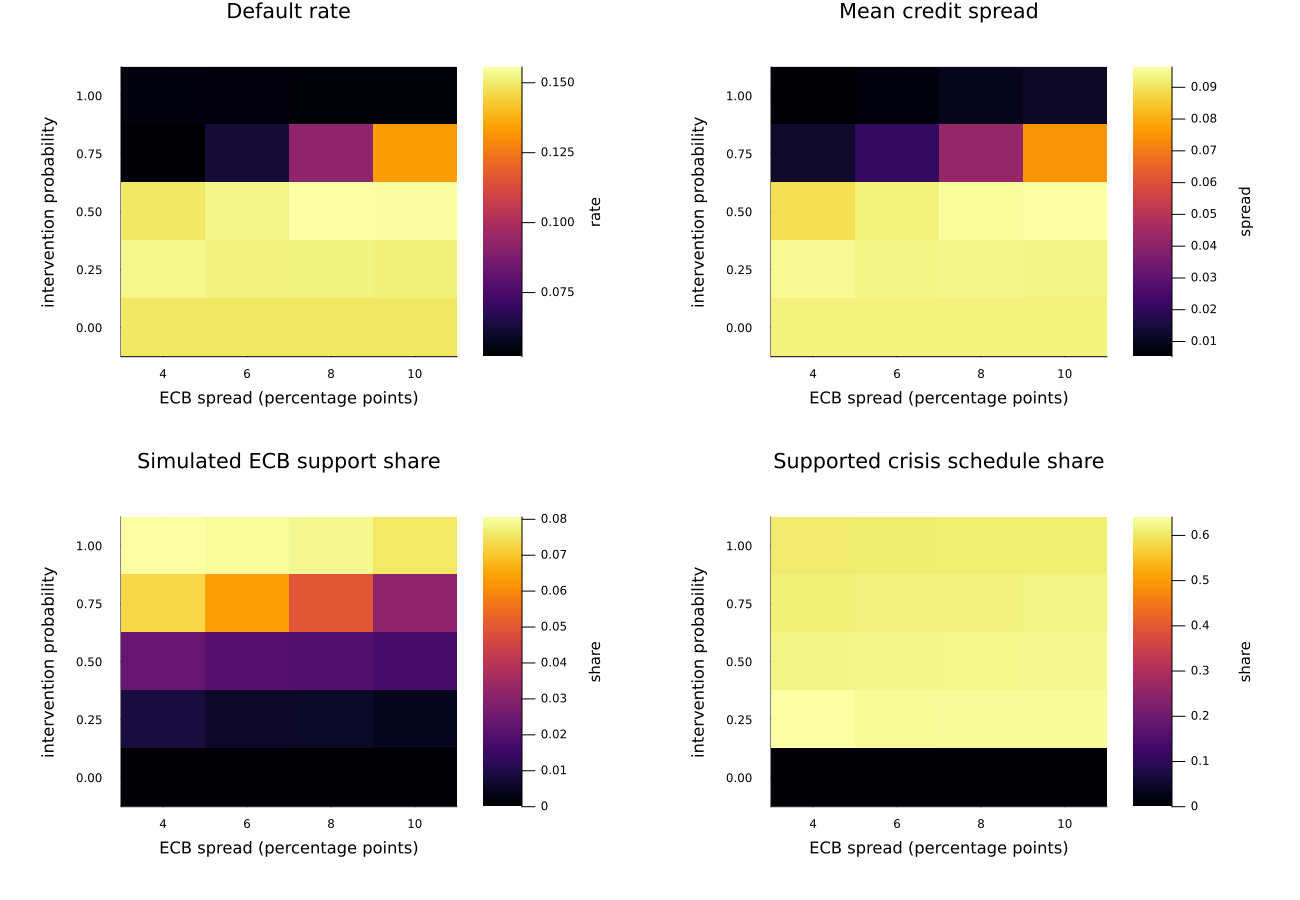

In [188]:
# Heatmaps of policy-grid simulated outcomes.
metric_matrix(field) = Float64[getfield(grid_results.summary[i, j], field) for i in eachindex(grid_results.prob_grid), j in eachindex(grid_results.spread_grid)]
x_spread = 100 .* grid_results.spread_grid
y_prob = grid_results.prob_grid

p_grid_default = heatmap(x_spread, y_prob, metric_matrix(:default_rate),
    xlabel = "ECB spread (percentage points)", ylabel = "intervention probability",
    title = "Default rate", colorbar_title = "rate")
p_grid_spread = heatmap(x_spread, y_prob, metric_matrix(:mean_credit_spread),
    xlabel = "ECB spread (percentage points)", ylabel = "intervention probability",
    title = "Mean credit spread", colorbar_title = "spread")
p_grid_use = heatmap(x_spread, y_prob, metric_matrix(:ecb_support_share),
    xlabel = "ECB spread (percentage points)", ylabel = "intervention probability",
    title = "Simulated ECB support share", colorbar_title = "share")
p_grid_schedule = heatmap(x_spread, y_prob, metric_matrix(:supported_schedule_share),
    xlabel = "ECB spread (percentage points)", ylabel = "intervention probability",
    title = "Supported crisis schedule share", colorbar_title = "share")

fig_grid_heatmap = plot(p_grid_default, p_grid_spread, p_grid_use, p_grid_schedule,
    layout = (2, 2), size = (1300, 900))
savefig(fig_grid_heatmap, joinpath(figure_dir, "ecb_policy_grid_heatmaps.png"))
display(fig_grid_heatmap)

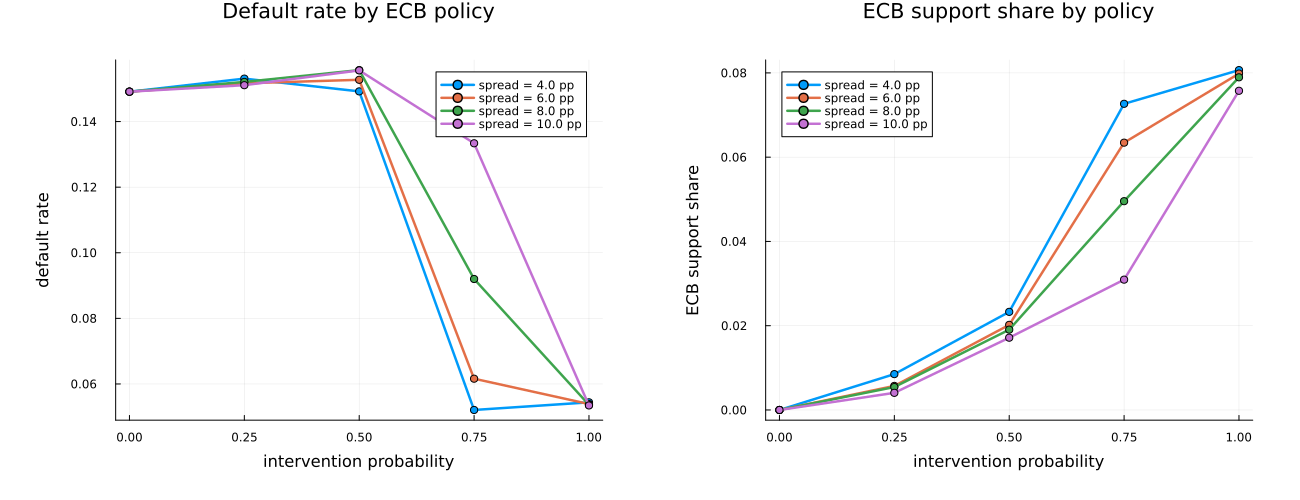

In [189]:
# Line plots of policy-grid outcomes by intervention probability.
p_grid_default_lines = plot(xlabel = "intervention probability", ylabel = "default rate",
    title = "Default rate by ECB policy")
p_grid_support_lines = plot(xlabel = "intervention probability", ylabel = "ECB support share",
    title = "ECB support share by policy")
for (j, spread) in enumerate(grid_results.spread_grid)
    label = "spread = $(round(100 * spread, digits = 0)) pp"
    plot!(p_grid_default_lines, grid_results.prob_grid,
        [grid_results.summary[i, j].default_rate for i in eachindex(grid_results.prob_grid)],
        linewidth = 2.5, marker = :circle, label = label)
    plot!(p_grid_support_lines, grid_results.prob_grid,
        [grid_results.summary[i, j].ecb_support_share for i in eachindex(grid_results.prob_grid)],
        linewidth = 2.5, marker = :circle, label = label)
end

fig_grid_lines = plot(p_grid_default_lines, p_grid_support_lines, layout = (1, 2), size = (1300, 500))
savefig(fig_grid_lines, joinpath(figure_dir, "ecb_policy_grid_lines.png"))
display(fig_grid_lines)